In [1]:
import glob

import h5py
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
import time

from tqdm import trange
import time
import xarray as xr
import scipy.cluster.hierarchy as shc

In [2]:
def write_memory_mapped_array(path_to_mocofiles, save_path, shape):

    # write memory mapped brain array to h5 file
    brain_array = np.memmap(f'{save_path}', dtype=np.float32, mode="w+", shape=shape)
    for i in range(shape[-1]):
        single_nii = f'{path_to_mocofiles}/motion_corrected_volume{i}.nii'
        file = nib.load(single_nii)  # shape (x, y, z)
        data = file.get_fdata()
        brain_array[..., i] = data

    # 3. Flush changes to disk and close the file handle safely
    brain_array.flush()
    del brain_array

def T_grab(path_to_mocofiles):
    all_niis = glob.glob(f'{path_to_mocofiles}/motion_corrected_*.nii')
    return len(all_niis)

In [3]:
experiment_list = glob.glob('/Volumes/AhmedLab/princess/data/pIP10/processed/*win01*')[4:]
print(experiment_list)

['/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002']


In [20]:
from maui_analysis.supervoxels import load_brain_array
T = 10
brain_array = load_brain_array(experiment_list[1], T)

# print(f"Brain Array Assignment Completed in {time.time() - start_time}s")

print(f'saving to memory mapped array')
save_dir = f'/Users/princesst/Documents/pIP10_results'
save_path = f'{save_dir}/{os.path.basename(experiment_list[1])}_brainarray.h5'
mem_arr = np.memmap(f'{save_path}', dtype=np.float32, mode="w+", shape=brain_array.shape)
mem_arr[:] = brain_array[:]
mem_arr.flush()
del mem_arr

100%|██████████| 10/10 [00:06<00:00,  1.61it/s]

saving to memory mapped array


(512, 512, 11, 10)


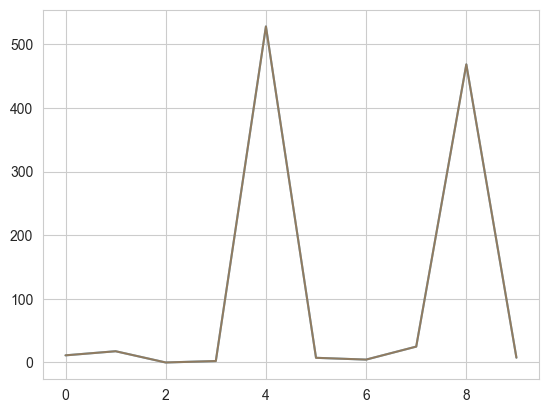

In [23]:
mem_arr = np.memmap(f'{save_path}', dtype=np.float32, mode="r", shape=brain_array.shape)
print(mem_arr.shape)

mem_arr[...,-1]
plt.plot(mem_arr[100,250,10, :])
plt.plot(brain_array[100,250,10, :], alpha=0.5)

In [90]:

# experiment_list = glob.glob('/Volumes/AhmedLab/princess/data/pIP10/processed/*GC8m_*win01*')
# save_dir = f'/Volumes/AhmedLab/princess/data/pIP10/processed/26_08_17'
#
# start = time.time()
# for i in experiment_list:
#     path_to_mocofiles = i
#     # T = T_grab(path_to_mocofiles)
#     T = 700
#     shape = [512, 512, 11, T]
#     print(f'array shape: {shape}')
#
#     save_path = f'{save_dir}/{os.path.basename(path_to_mocofiles)}_brainarray.h5'
#     # start = time.time()
#     # print('writing brain array')
#     # write_memory_mapped_array(path_to_mocofiles, save_path, shape)
#     # end = time.time()
#     # print(f'time taken to build and save array: {end-start}')
#     break


array shape: [512, 512, 11, 700]


In [4]:
path_to_mocofiles = experiment_list[0]
T = T_grab(path_to_mocofiles)
print(T)

2779


In [ ]:
save_path = f'{save_dir}/{os.path.basename(path_to_mocofiles)}_brainarray.h5'
save_path = 'brain_array.h5'
T = T_grab(path_to_mocofiles)
shape = [512, 512, 11, T]
start = time.time()
brain_array = np.memmap(f'{save_path}', dtype=np.float32, mode="w+", shape=shape)
print(f'for {shape}, took {time.time() - start} seconds')
for i in range(shape[-1]):
    single_nii = f'{path_to_mocofiles}/motion_corrected_volume{i}.nii'
    file = nib.load(single_nii)  # shape (x, y, z)
    data = file.get_fdata()
    brain_array[..., i] = data

mm[:] = my_array[:]

In [9]:
fly='03'
win='1'

file = glob.glob(f'/Users/princesst/Documents/pIP10_results/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001_brainarray.h5')[0]
shape = [512, 512, 11, 700]
brain_array = np.memmap(file, dtype=np.float32, mode='r', shape=shape)

In [ ]:
r

In [10]:
NCLUSTERS = 20
T = shape[-1]
BASE_DIRECTORY = '/Volumes/AhmedLab/princess/data/pIP10/'
PROCESSED_DIR = f'{BASE_DIRECTORY}/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/'
file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/20_supervoxels.h5')[0]
with h5py.File(file, 'r') as f:
    cluster_labels = f['labels'][...]

In [11]:
from maui_analysis.supervoxels import  calculate_zscoredF_voxels, get_supervoxel_mean_2d
import seaborn as sns
def calculate_supervoxel_signal(supervoxel_labels, df, T, n_clusters):
    n_slices = df.shape[0]
    signal = np.empty(shape=(df.shape[0], n_clusters, T))
    for slice in range(df.shape[0]):
        mean_signal = np.empty(shape=(df.shape[2], n_clusters))  # t, z
        for vol in range(df.shape[2]):
            mean_supervox, _ = get_supervoxel_mean_2d(df[slice, :, vol], supervoxel_labels[slice], n_clusters)
            mean_signal[vol] = mean_supervox
        signal[slice] = mean_signal.T
        return signal
def plot_zscored_activity(clusters_toplot, signal_xarray, yshift = 1):
    fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(20, len(clusters_toplot)))
    # yshift = 1
    # n_lines = len(clusters_toplot)
    palette_colors = sns.color_palette("Blues", len(clusters_toplot))

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")

import matplotlib.colors as colors
def plot_spatial_location(clusters_toplot, cluster_2d_arr, brain_dimensions):
    fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(40, 40), constrained_layout=True)
    palette_colors = sns.color_palette("twilight", 25)
    cmap = ListedColormap(palette_colors)

    axes = axes.flatten()
    blank_brain = create_blank_brain(cluster_2d_arr)
    for cluster in clusters_toplot:
        identify_single_cluster(cluster_2d_arr, blank_brain, cluster)

    blank_brain_clusters = blank_brain.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])
    raw_brain_clusters = cluster_2d_arr.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])

    for idx in range(brain_dimensions[2]):
        ax = axes[idx]
        # ax.imshow(raw_brain_clusters[idx].T, cmap="gray_r", alpha=0.7)
        ax.imshow(blank_brain_clusters[idx].T, cmap=cmap, alpha=1)
        ax.set_title(f"Slice {idx}")

    for j in range(brain_dimensions[2], len(axes)):
        fig.delaxes(axes[j])
from maui_codebook.visualizations import *

(11, 512, 512)


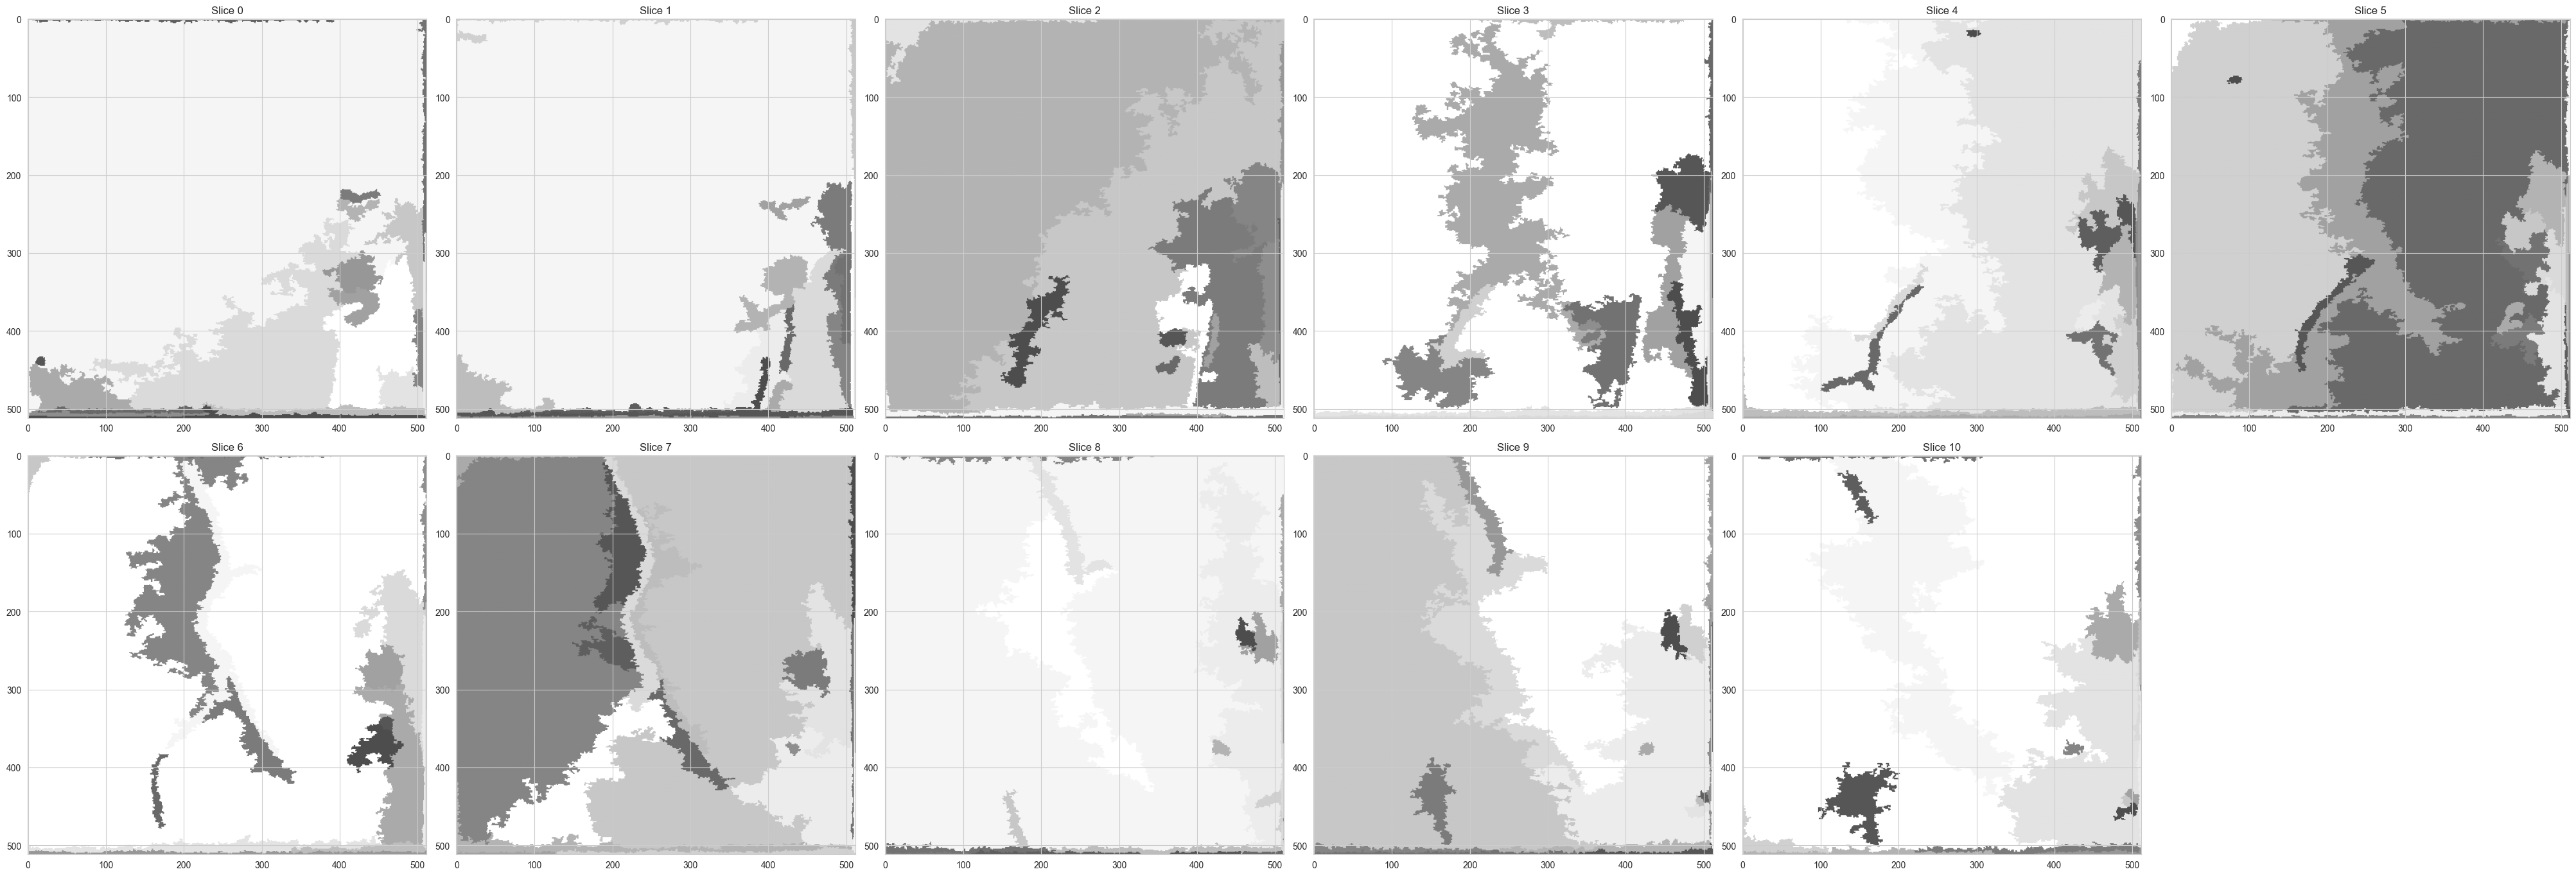

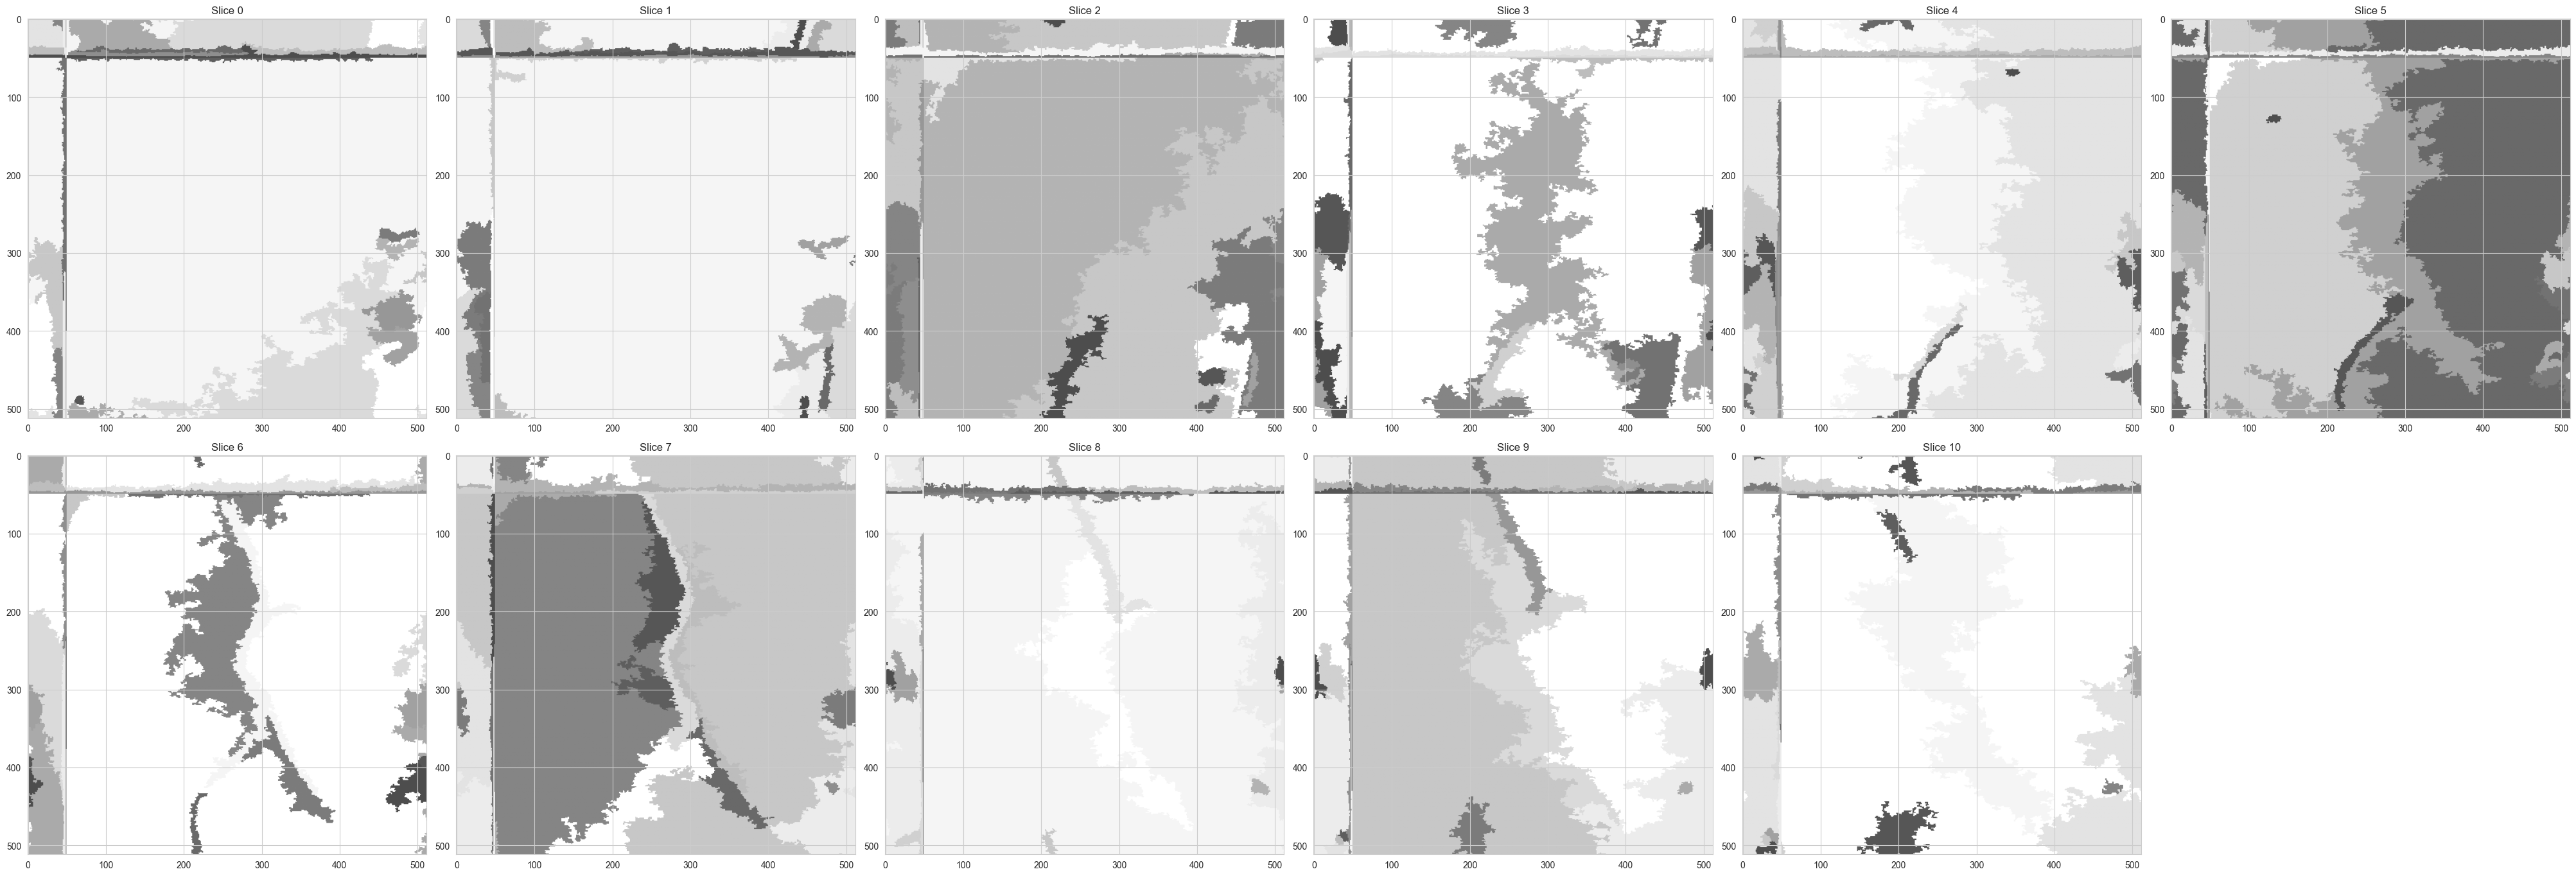

In [13]:
# on true supervoxels
df = calculate_zscoredF_voxels(brain_array)
signal = calculate_supervoxel_signal(cluster_labels, df, T, NCLUSTERS)

sh_signal = calculate_supervoxel_signal(shifted_labels, df, T, NCLUSTERS)

In [14]:
# format into xarrays
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': range(signal.shape[2])}
)
sh_signal_xr = xr.DataArray(
    data=sh_signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': range(sh_signal.shape[2])}
)

(11, 262144)


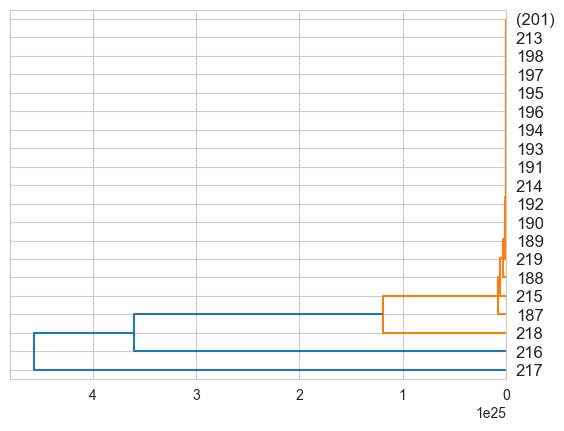

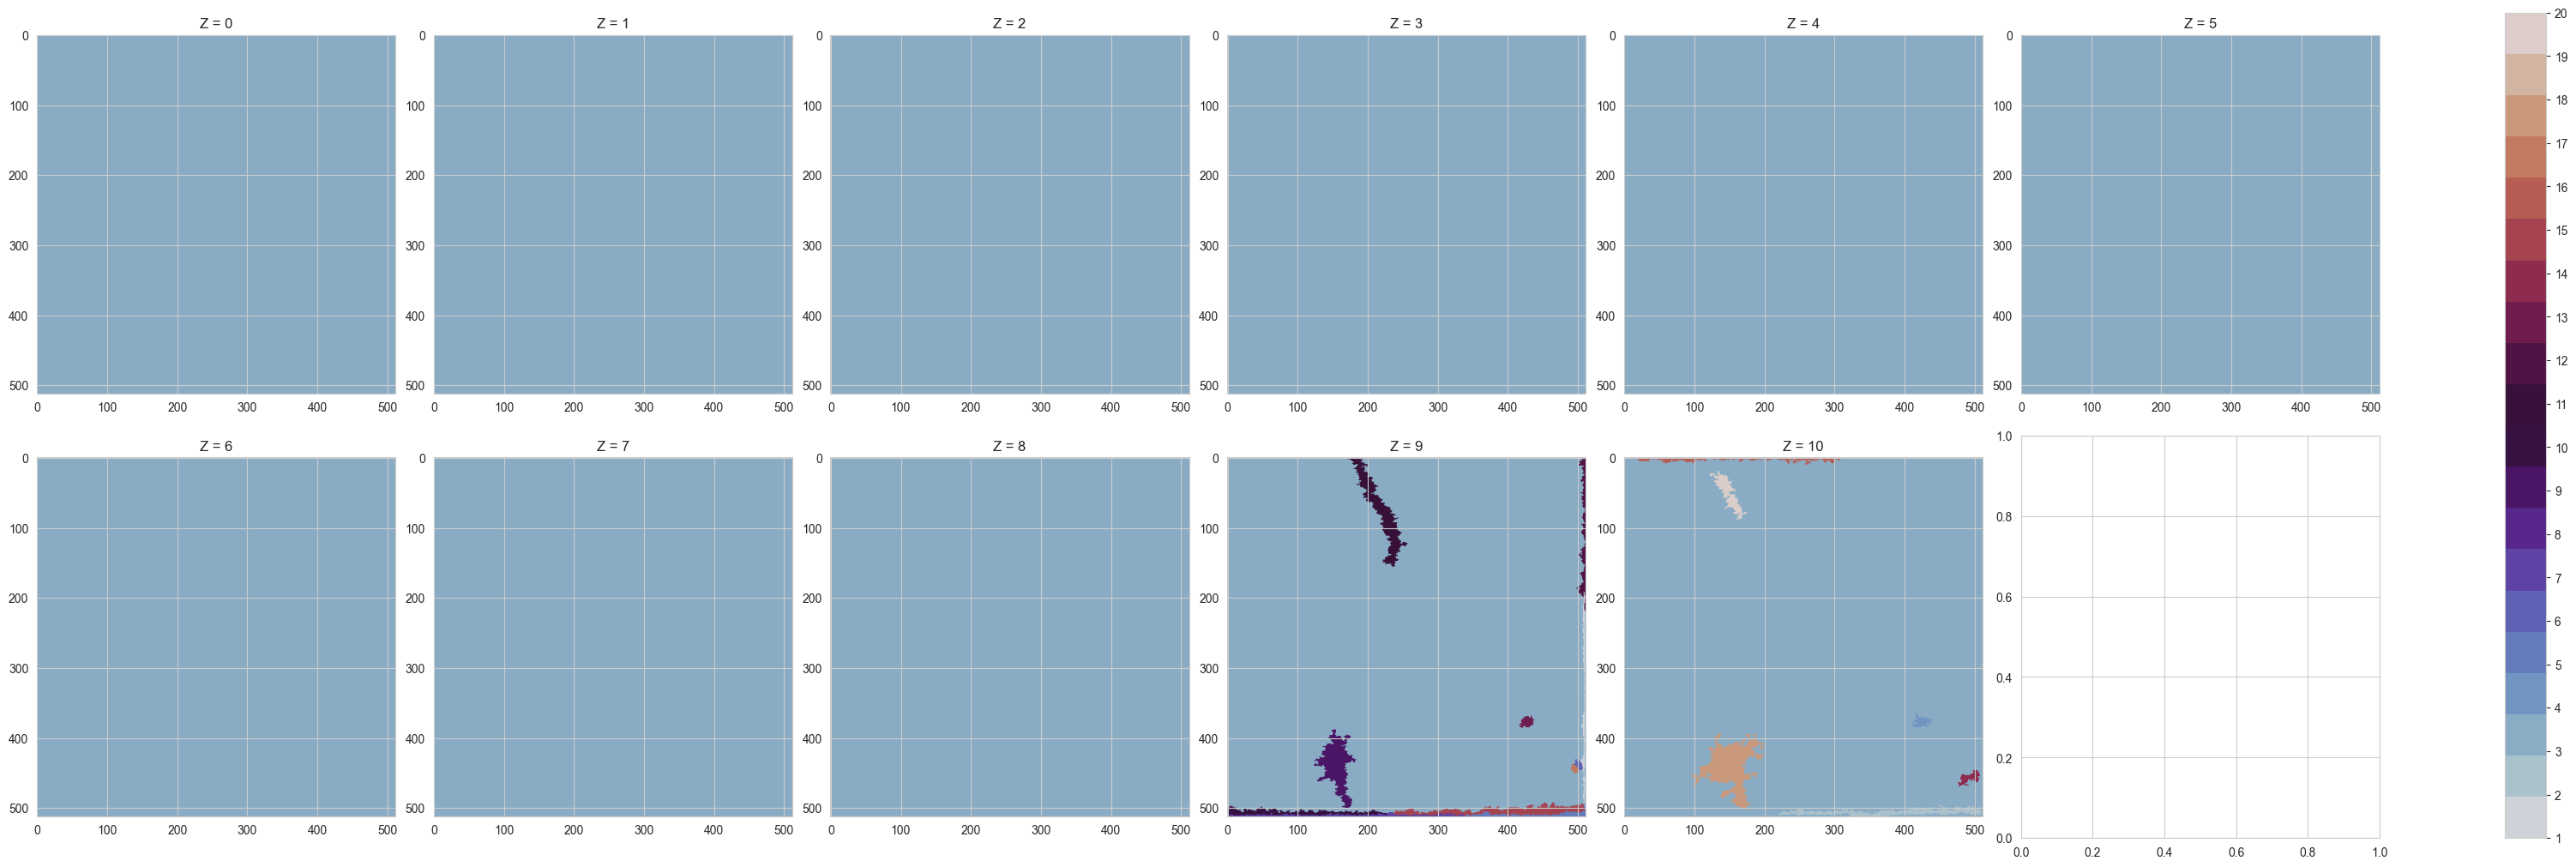

In [15]:
# cluster supervoxels by activity over time
NCLUSTERS = 20
SLICES = shape[2]
supervox_signal = signal_xr.stack(supervoxel=['zposs', 'roi']).T
Z = shc.linkage(supervox_signal, method='ward')
_ = shc.dendrogram(Z, orientation='left', truncate_mode='lastp', p=NCLUSTERS)
clust_labels = shc.fcluster(Z, NCLUSTERS, criterion='maxclust')
grouped_sv = supervox_signal.assign_coords(cluster = ('supervoxel', clust_labels)).set_index(supervoxel='cluster', append=True)

# color spatial maps by cluster id
clusters_spatial = np.empty(cluster_labels.shape, dtype=int)
print(clusters_spatial.shape)
for z,px_list in enumerate(cluster_labels):
    # find cluster value
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for px, sv in enumerate(px_list):
        clusters_spatial[z,px] = values[sv]

norm = colors.Normalize(vmin=1, vmax=NCLUSTERS)
palette_colors = sns.color_palette("twilight", NCLUSTERS)
cmap = ListedColormap(palette_colors)
#
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(30, 10), constrained_layout=True)
axes = axes.flatten()
for z in range(SLICES):
    ax = axes[z]
    image = np.reshape(clusters_spatial[z],[512,512])
    map = ax.imshow(image.T, cmap=cmap, norm=norm)
    ax.set_title(f'Z = {z}')
plt.colorbar(map, ax=axes.ravel(),ticks=np.arange(1,NCLUSTERS+1))

In [30]:
# select cool cluster
COOL_CLUSTER = 22


supervoxel_subset = []
DIMENSIONS = [shape[0], shape[1]]
for z in range(0, 5):  # slice range
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for idx, v in enumerate(values):
        if v == COOL_CLUSTER:
            supervoxel_subset.append([z, idx])
print(supervoxel_subset)
print(len(supervoxel_subset))
indexs = [0, 1]
pip_rois = [supervoxel_subset[x] for x in indexs]
print(len(pip_rois))
plot_spatial_location(pip_rois, cluster_labels, [512,512, 11])

[]
0


IndexError: list index out of range